## imports

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", 100)

data_path = '../data/togo-dapaong_qc.csv'
df = pd.read_csv(data_path)


df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.sort_values("Timestamp").drop_duplicates(subset=["Timestamp"]).reset_index(drop=True)

df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


## data cleaning

In [2]:
display(df.describe(include="all"))
nulls = df.isna().mean().sort_values(ascending=False)
display(nulls)
over5 = nulls[nulls > 0.05]
print("Columns with >5% nulls:", list(over5.index))


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


Comments         1.0
GHI              0.0
Timestamp        0.0
DNI              0.0
DHI              0.0
ModB             0.0
ModA             0.0
RH               0.0
WS               0.0
WSgust           0.0
Tamb             0.0
WSstdev          0.0
WD               0.0
BP               0.0
WDstdev          0.0
Cleaning         0.0
Precipitation    0.0
TModA            0.0
TModB            0.0
dtype: float64

Columns with >5% nulls: ['Comments']


## Solar plausibilty rules

In [3]:
dfc = df.copy()

# Irradiance must be non-negative
for c in ["GHI","DNI","DHI","ModA","ModB"]:
    if c in dfc: dfc.loc[dfc[c] < 0, c] = np.nan

# Physical relationship: DHI ≤ GHI
if {"DHI","GHI"}.issubset(dfc.columns):
    dfc.loc[dfc["DHI"] > dfc["GHI"], "DHI"] = np.nan

# RH in [0,100]
if "RH" in dfc: dfc.loc[(dfc["RH"] < 0) | (dfc["RH"] > 100), "RH"] = np.nan

# Wind speeds ≥ 0
for c in ["WS","WSgust","WSstdev"]:
    if c in dfc: dfc.loc[dfc[c] < 0, c] = np.nan

# Wind direction in [0,360]
if "WD" in dfc: dfc.loc[(dfc["WD"] < 0) | (dfc["WD"] > 360), "WD"] = np.nan
if "WDstdev" in dfc: dfc.loc[dfc["WDstdev"] < 0, "WDstdev"] = np.nan

# Barometric pressure in [800,1100] hPa
if "BP" in dfc: dfc.loc[(dfc["BP"] < 800) | (dfc["BP"] > 1100), "BP"] = np.nan

# Precipitation ≥ 0
if "Precipitation" in dfc: dfc.loc[dfc["Precipitation"] < 0, "Precipitation"] = np.nan

# Temperatures within [-50, 80] °C
for c in ["Tamb","TModA","TModB"]:
    if c in dfc: dfc.loc[(dfc[c] < -50) | (dfc[c] > 80), c] = np.nan

df_after_rules = dfc.copy()
df_after_rules.describe().T.head(10)


,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-04-25 12:00:30.000000768,2021-10-25 00:01:00,2022-01-24 06:00:45,2022-04-25 12:00:30,2022-07-25 18:00:15,2022-10-25 00:00:00,NaN
GHI,268215.0,454.081218,0.0,156.5,430.3,743.9,1424.0,319.09601
DNI,525600.0,151.258469,0.0,0.0,0.0,246.4,1004.5,250.956962
DHI,497616.0,117.827162,0.0,0.0,0.0,219.6,805.7,158.568689
ModA,525600.0,226.144375,0.0,0.0,4.4,422.525,1380.0,317.346938
ModB,525600.0,219.568588,0.0,0.0,4.3,411.0,1367.0,307.93251
Tamb,525600.0,27.751788,14.9,24.2,27.2,31.1,41.4,4.758023
RH,525600.0,55.01316,3.3,26.5,59.3,80.8,99.8,28.778732
WS,525600.0,2.368093,0.0,1.4,2.2,3.2,16.1,1.462668
WSgust,525600.0,3.22949,0.0,1.9,2.9,4.4,23.1,1.882565


## Z- Score outlier

In [4]:
z_cols = [c for c in ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"] if c in dfc.columns]
for c in z_cols:
    s = pd.to_numeric(dfc[c], errors="coerce")
    mask = s.notna()
    if mask.sum() > 0:
        z = stats.zscore(s[mask], nan_policy="omit")
        out_mask = pd.Series(False, index=dfc.index)
        out_mask[mask.index[mask]] = np.abs(z) > 3
        dfc.loc[out_mask, c] = np.nan

df_after_outliers = dfc.copy()
dfc[z_cols].describe()


,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,268210.000000,524538.000000,494736.000000,525463.000000,525394.000000,522090.000000,521685.000000
mean,454.063267,149.671384,114.846223,225.884852,219.188607,2.331217,3.175654
std,319.071898,248.715008,154.111140,316.980197,307.393028,1.392819,1.776922
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,156.500000,0.000000,0.000000,0.000000,0.000000,1.400000,1.900000
50%,430.300000,0.000000,0.000000,4.300000,4.200000,2.200000,2.900000
75%,743.900000,242.600000,216.100000,422.050000,410.300000,3.200000,4.400000
max,1408.000000,904.100000,593.500000,1178.000000,1143.000000,6.700000,8.800000


## Medain Imputation

In [5]:
num_cols = dfc.select_dtypes(include=[np.number]).columns
for c in num_cols:
    med = dfc[c].median()
    dfc[c] = dfc[c].fillna(med)

df_clean = dfc.copy()
df_clean.info()


c:\Users\user\Downloads\Solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  float64       
 14  Cleaning       525600 non-null  int64         
 15  

## quick profiling and missingness check point

In [ ]:
display(df.describe(include="all").T.round(3))                     # raw
display(df_after_rules[z_cols].describe().T.round(3))              # after solar rules
display(df_after_outliers[z_cols].describe().T.round(3))           # after outliers
display(df_clean.describe(include="all").T.round(3))               # final
missing = df_clean.isna().mean().sort_values(ascending=False)
missing.head(12)


## Time - series

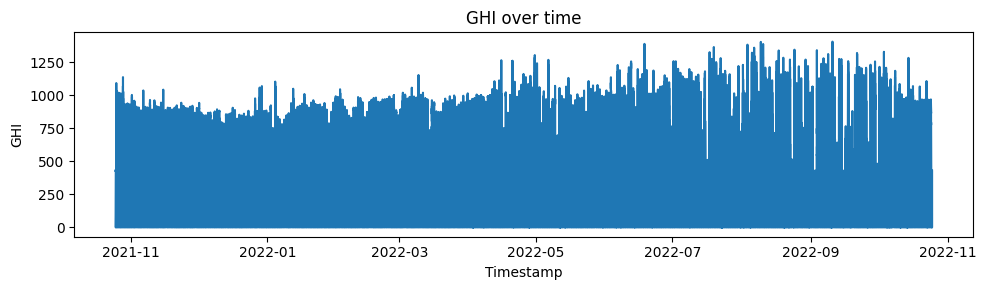

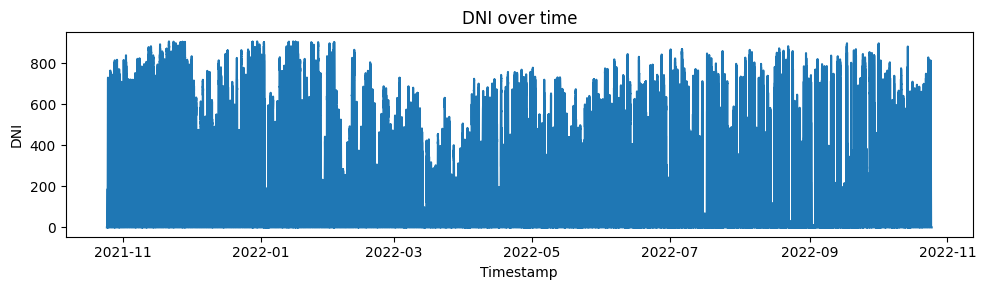

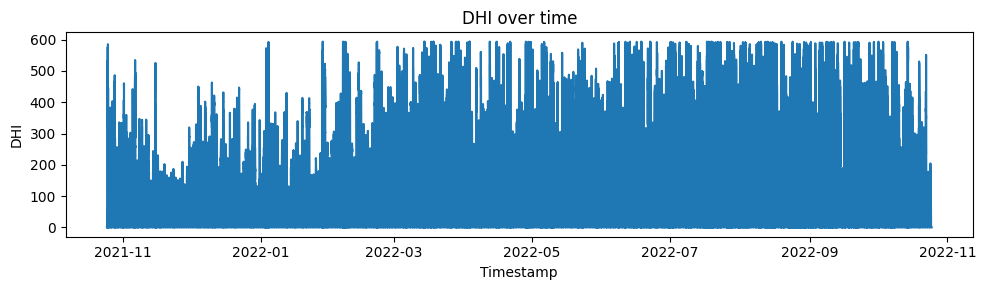

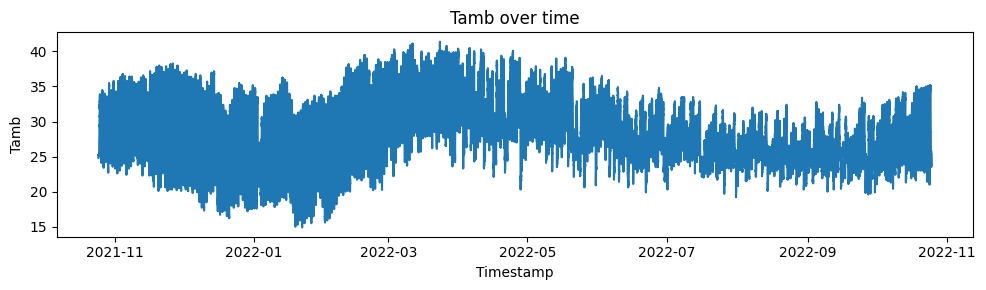

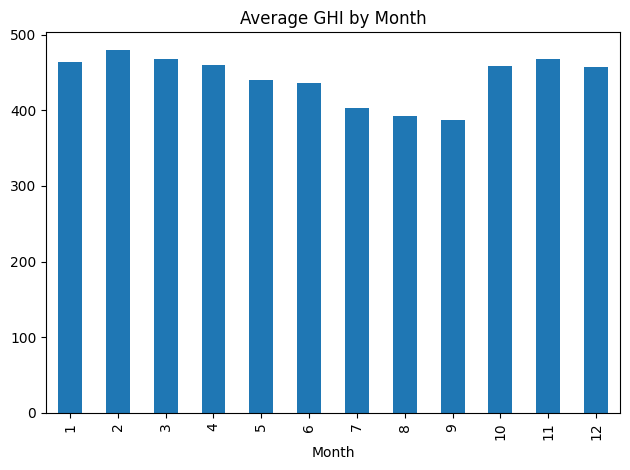

In [6]:
if "Timestamp" in df_clean:
    df_clean["Month"] = df_clean["Timestamp"].dt.month
    df_clean["Hour"]  = df_clean["Timestamp"].dt.hour

    for col in ["GHI","DNI","DHI","Tamb"]:
        if col in df_clean.columns:
            plt.figure(figsize=(10,3))
            plt.plot(df_clean["Timestamp"], df_clean[col])
            plt.title(f"{col} over time")
            plt.xlabel("Timestamp"); plt.ylabel(col)
            plt.tight_layout(); plt.show()

    if "GHI" in df_clean.columns:
        plt.figure()
        df_clean.groupby("Month")["GHI"].mean().plot(kind="bar", title="Average GHI by Month")
        plt.tight_layout(); plt.show()


 ## cleaning and impact

,ModA,ModB
Cleaning,,
0,225.661615,218.936860
1,535.186477,532.211744


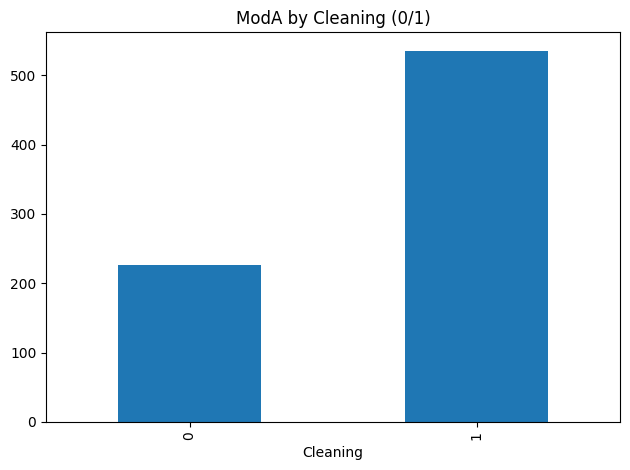

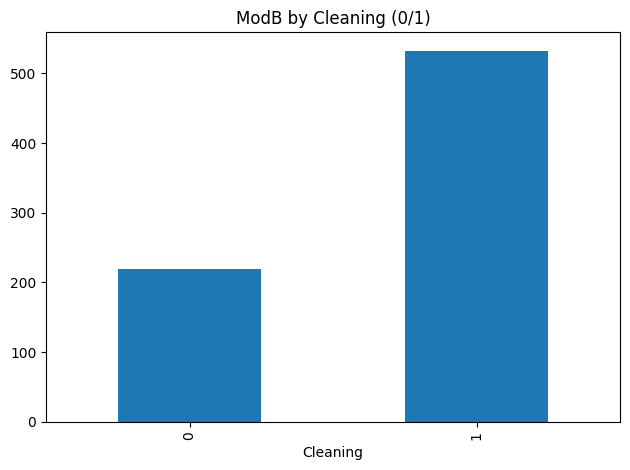

In [7]:
if "Cleaning" in df_clean.columns and {"ModA","ModB"}.issubset(df_clean.columns):
    avg = df_clean.groupby("Cleaning")[["ModA","ModB"]].mean()
    display(avg)
    for col in ["ModA","ModB"]:
        plt.figure()
        avg[col].plot(kind="bar", title=f"{col} by Cleaning (0/1)")
        plt.tight_layout(); plt.show()


In [ ]:
## correlation

,GHI,DNI,DHI,TModA,TModB,Tamb,RH,WS,WSgust
GHI,1.000,0.672,0.521,0.606,0.623,0.365,-0.230,0.258,0.273
DNI,0.672,1.000,0.567,0.764,0.780,0.502,-0.319,0.370,0.395
DHI,0.521,0.567,1.000,0.791,0.810,0.489,-0.169,0.402,0.429
TModA,0.606,0.764,0.791,1.000,0.984,0.806,-0.245,0.351,0.387
TModB,0.623,0.780,0.810,0.984,1.000,0.741,-0.225,0.375,0.410
Tamb,0.365,0.502,0.489,0.806,0.741,1.000,-0.400,0.217,0.246
RH,-0.230,-0.319,-0.169,-0.245,-0.225,-0.400,1.000,-0.156,-0.142
WS,0.258,0.370,0.402,0.351,0.375,0.217,-0.156,1.000,0.962
WSgust,0.273,0.395,0.429,0.387,0.410,0.246,-0.142,0.962,1.000


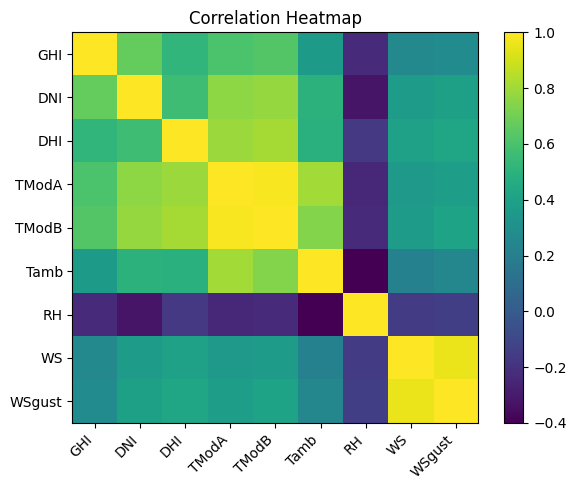

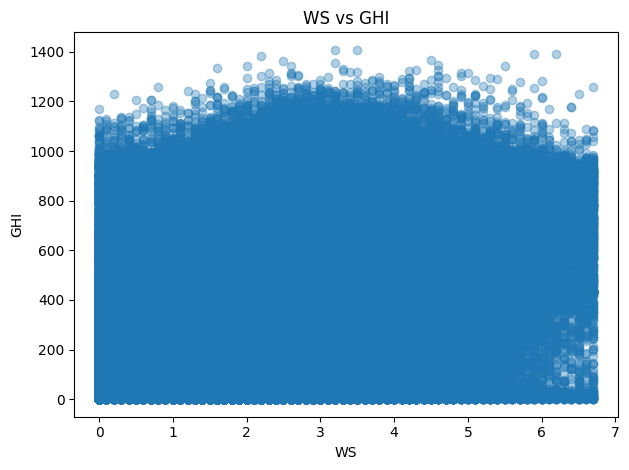

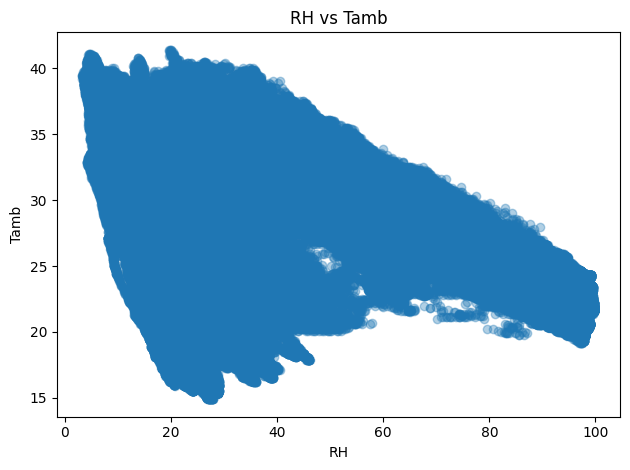

In [8]:
corr_cols = [c for c in ["GHI","DNI","DHI","TModA","TModB","Tamb","RH","WS","WSgust"] if c in df_clean.columns]
if len(corr_cols) >= 2:
    cmat = df_clean[corr_cols].corr()
    display(cmat.round(3))
    plt.figure(figsize=(6,5))
    plt.imshow(cmat, aspect="auto")
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.colorbar(); plt.title("Correlation Heatmap")
    plt.tight_layout(); plt.show()

if {"WS","GHI"}.issubset(df_clean.columns):
    plt.figure(); plt.scatter(df_clean["WS"], df_clean["GHI"], alpha=0.35)
    plt.xlabel("WS"); plt.ylabel("GHI"); plt.title("WS vs GHI")
    plt.tight_layout(); plt.show()

if {"RH","Tamb"}.issubset(df_clean.columns):
    plt.figure(); plt.scatter(df_clean["RH"], df_clean["Tamb"], alpha=0.35)
    plt.xlabel("RH"); plt.ylabel("Tamb"); plt.title("RH vs Tamb")
    plt.tight_layout(); plt.show()


## wind and distribution

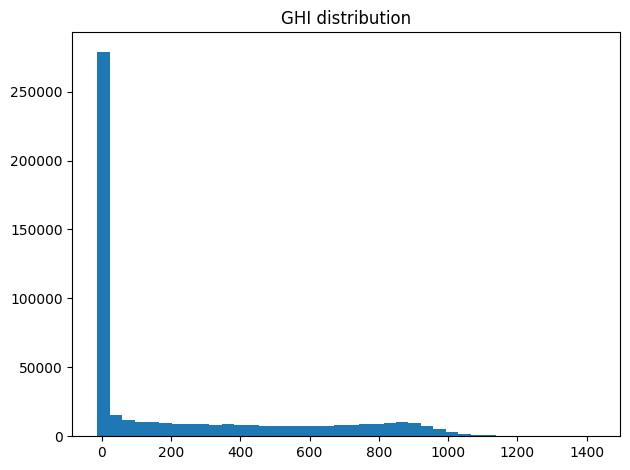

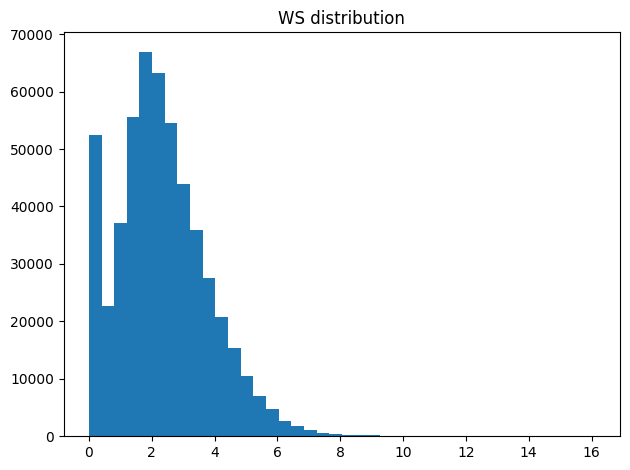

Windrose not available or data missing; skipping. Reason: No module named 'windrose'


In [9]:
# Histograms
for col in ["GHI","WS"]:
    if col in df.columns:
        plt.figure(); plt.hist(df[col].dropna(), bins=40)
        plt.title(f"{col} distribution"); plt.tight_layout(); plt.show()

# Wind rose is optional (needs 'windrose' package); skip in CI, do locally if installed
try:
    from windrose import WindroseAxes
    if {"WS","WD"}.issubset(df.columns):
        ax = WindroseAxes.from_ax()
        ax.bar(df["WD"], df["WS"], normed=True, opening=0.8)
        ax.set_title("Wind Rose (WS by WD)")
        plt.show()
except Exception as e:
    print("Windrose not available or data missing; skipping. Reason:", e)


## Temprature / RH influence

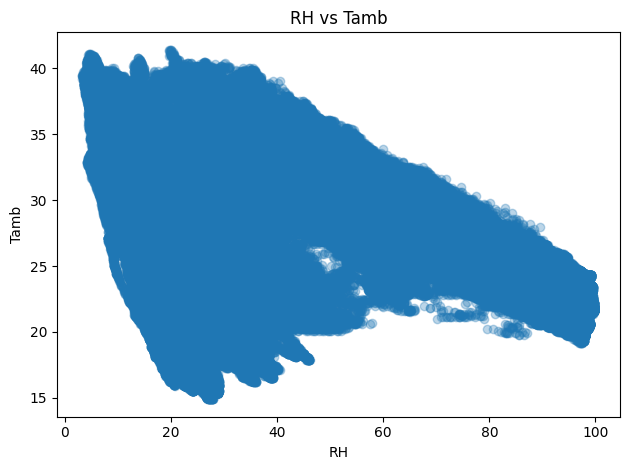

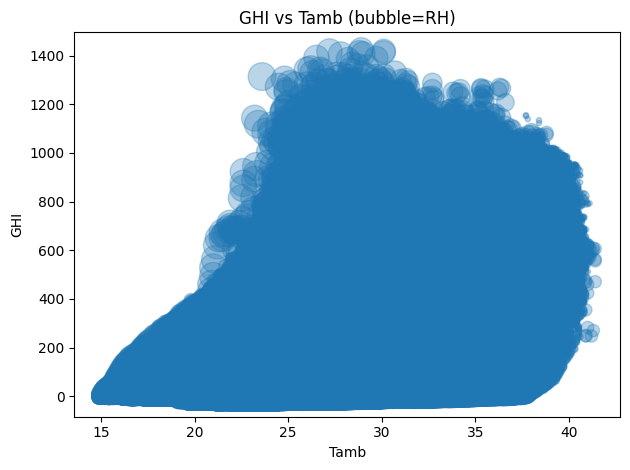

In [10]:
# Simple check of RH influence on Tamb (scatter w/ alpha)
if {"RH","Tamb"}.issubset(df.columns):
    plt.figure(); plt.scatter(df["RH"], df["Tamb"], alpha=0.3)
    plt.xlabel("RH"); plt.ylabel("Tamb"); plt.title("RH vs Tamb")
    plt.tight_layout(); plt.show()

# Bubble: GHI vs Tamb with bubble size = RH (or BP)
size_col = "RH" if "RH" in df.columns else ("BP" if "BP" in df.columns else None)
if size_col and {"GHI","Tamb"}.issubset(df.columns):
    s = df[size_col].astype(float)
    s = (s - s.min()) / (s.max() - s.min() + 1e-9) * 400 + 10
    plt.figure(); plt.scatter(df["Tamb"], df["GHI"], s=s, alpha=0.3)
    plt.xlabel("Tamb"); plt.ylabel("GHI"); plt.title(f"GHI vs Tamb (bubble={size_col})")
    plt.tight_layout(); plt.show()


## Bubble chart

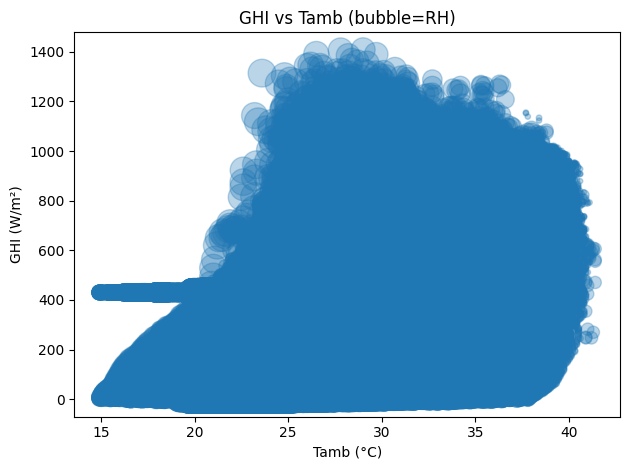

In [11]:
size_col = "RH" if "RH" in df_clean.columns else ("BP" if "BP" in df_clean.columns else None)
if size_col and {"GHI","Tamb"}.issubset(df_clean.columns):
    s = df_clean[size_col].astype(float)
    s = (s - s.min()) / (s.max() - s.min() + 1e-9) * 400 + 10
    plt.figure()
    plt.scatter(df_clean["Tamb"], df_clean["GHI"], s=s, alpha=0.3)
    plt.xlabel("Tamb (°C)"); plt.ylabel("GHI (W/m²)")
    plt.title(f"GHI vs Tamb (bubble={size_col})")
    plt.tight_layout(); plt.show()


## Exporting cleaned csv

In [12]:
Path("data").mkdir(exist_ok=True)
out = Path("data") / "togo_clean.csv"
df_clean.to_csv(out, index=False)
print(f"[OK] saved: {out}")
if "Timestamp" in df_clean:
    print("Timestamp dtype:", df_clean["Timestamp"].dtype)
print("Rows:", len(df_clean), "Cols:", len(df_clean.columns))


[OK] saved: data\togo_clean.csv
Timestamp dtype: datetime64[ns]
Rows: 525600 Cols: 21
